# Reproducing *From the Gold Room to Northern Prices*

This notebook is organized as a real research notebook rather than a single wrapper cell.
It loads the greenback series from Mitchell (1903) tables in `data/`, downloads the FRED/NBER
price indices, reproduces the paper's figures and tables, and leaves each intermediate object
visible for inspection.

**Paper:** Miguel González Calvo, *From the Gold Room to Northern Prices: Greenback Revaluations and Pass-Through in the Union, 1862-1865*

## Notebook roadmap

1. Import packages and define helpers
2. Load the greenback series from Mitchell (1903) and the monthly FRED/NBER price indices
3. Clean and inspect the daily and monthly data
4. Reproduce the main figures
5. Estimate the pass-through regressions with HAC standard errors
6. Export tables, figures, and cleaned datasets

In [28]:
# Uncomment if you need to install packages locally.
# %pip install pandas numpy matplotlib requests statsmodels


In [29]:
from __future__ import annotations

import io
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List, Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
from statsmodels.stats.sandwich_covariance import cov_hac

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")

In [30]:
# Data sources
FRED_CSV = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

GENERAL_SERIES = "M04051USM324NNBR"      # General price level, monthly
WHOLESALE_SERIES = "M0448AUSM323NNBR"    # Wholesale price index, monthly

START = "1862-01-01"
END = "1865-12-31"

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
OUTDIR = ROOT / "output"
OUTDIR.mkdir(exist_ok=True)

print("Data folder:", DATA_DIR.resolve())
print("Output folder:", OUTDIR.resolve())

Data folder: /Users/miguel/workspace/american-civl-war/data
Output folder: /Users/miguel/workspace/american-civl-war/output


## Helper functions

The functions below are kept separate so you can run and inspect each stage manually.


In [31]:
@dataclass
class ModelResult:
    dependent: str
    model: str
    beta0: float
    se0: float
    beta1: float | None
    se1: float | None
    beta2: float | None
    se2: float | None
    cumulative: float
    cumulative_se: float
    nobs: int
    r2: float


def download_fred_series(series_id: str) -> pd.Series:
    resp = requests.get(FRED_CSV.format(series_id=series_id), timeout=60)
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text))
    df.columns = [c.strip() for c in df.columns]
    # FRED uses "observation_date" (or historically "DATE") as the date column
    date_col = next(c for c in df.columns if "date" in c.lower())
    value_col = [c for c in df.columns if c != date_col][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    s = df.set_index(date_col)[value_col].sort_index()
    s.name = series_id
    return s


def normalize_to_base_100(s: pd.Series) -> pd.Series:
    return 100 * s / s.iloc[0]


def fit_ols_hac(y: pd.Series, X: pd.DataFrame, nlags: int = 1):
    aligned = pd.concat([y, X], axis=1).dropna()
    y_aligned = aligned.iloc[:, 0]
    X_aligned = sm.add_constant(aligned.iloc[:, 1:], has_constant="add")
    res = sm.OLS(y_aligned, X_aligned).fit()
    cov = cov_hac(res, nlags=nlags)
    return res, cov, aligned


def distributed_lag_result(df: pd.DataFrame, dep_col: str, label: str) -> list[ModelResult]:
    results = []

    X0 = pd.DataFrame({"dln_G_t": df["dln_gold_price_greenbacks"]})
    res0, cov0, aligned0 = fit_ols_hac(df[dep_col], X0, nlags=1)
    b0 = float(res0.params["dln_G_t"])
    se0 = float(np.sqrt(cov0[1, 1]))
    results.append(ModelResult(label, "Contemp.", b0, se0, None, None, None, None, b0, se0, int(aligned0.shape[0]), float(res0.rsquared)))

    Xdl = pd.DataFrame(
        {
            "dln_G_t": df["dln_gold_price_greenbacks"],
            "lag1": df["dln_gold_price_greenbacks"].shift(1),
            "lag2": df["dln_gold_price_greenbacks"].shift(2),
        }
    )
    resdl, covdl, aligneddl = fit_ols_hac(df[dep_col], Xdl, nlags=1)
    idx = {name: i for i, name in enumerate(resdl.params.index)}
    w = np.zeros(len(resdl.params))
    for nm in ["dln_G_t", "lag1", "lag2"]:
        w[idx[nm]] = 1.0
    cum = float(w @ resdl.params.values)
    cum_se = float(np.sqrt(w @ covdl @ w))

    results.append(
        ModelResult(
            dependent=label,
            model="DL(0-2)",
            beta0=float(resdl.params["dln_G_t"]),
            se0=float(np.sqrt(covdl[idx["dln_G_t"], idx["dln_G_t"]])),
            beta1=float(resdl.params["lag1"]),
            se1=float(np.sqrt(covdl[idx["lag1"], idx["lag1"]])),
            beta2=float(resdl.params["lag2"]),
            se2=float(np.sqrt(covdl[idx["lag2"], idx["lag2"]])),
            cumulative=cum,
            cumulative_se=cum_se,
            nobs=int(aligneddl.shape[0]),
            r2=float(resdl.rsquared),
        )
    )
    return results


def results_to_table(results: Iterable[ModelResult]) -> pd.DataFrame:
    rows = []
    for r in results:
        rows.append(
            {
                "Dependent variable": r.dependent,
                "Model": r.model,
                "Delta ln G_t": f"{r.beta0:.3f} ({r.se0:.3f})",
                "Lag 1": "" if r.beta1 is None else f"{r.beta1:.3f} ({r.se1:.3f})",
                "Lag 2": "" if r.beta2 is None else f"{r.beta2:.3f} ({r.se2:.3f})",
                "Cum. 0-2": f"{r.cumulative:.3f} ({r.cumulative_se:.3f})",
                "N": r.nobs,
                "R^2": round(r.r2, 3),
            }
        )
    return pd.DataFrame(rows)

## 1. Load and inspect the raw data

In [32]:
# Daily greenback series from Mitchell (1903), Appendix A, Table 2
greenback_daily = pd.read_csv(DATA_DIR / "mitchell_appendix_a_table2_daily_gold_prices.csv", comment="#")
greenback_daily["date"] = pd.to_datetime(
    greenback_daily[["year", "month", "day"]].rename(columns={"year": "year", "month": "month", "day": "day"})
)
greenback_daily["midpoint"] = (greenback_daily["highest"] + greenback_daily["lowest"]) / 2.0
greenback_daily = greenback_daily.query("@START <= date <= @END").reset_index(drop=True)

print(greenback_daily.shape)
greenback_daily.head()

(1228, 7)


,year,month,day,highest,lowest,date,midpoint
0,1862,1,1,99.5000,98.5200,1862-01-01,99.0100
1,1862,1,2,99.0000,98.1100,1862-01-02,98.5550
2,1862,1,3,98.0400,97.0000,1862-01-03,97.5200
3,1862,1,4,98.2600,98.0400,1862-01-04,98.1500
4,1862,1,6,97.3000,97.5600,1862-01-06,97.4300


In [33]:
# FRED/NBER monthly price series

general_price = download_fred_series(GENERAL_SERIES).rename("general_price_index")
wholesale_price = download_fred_series(WHOLESALE_SERIES).rename("wholesale_price_index")

pd.concat([general_price.head(), wholesale_price.head()], axis=1)


/var/folders/y4/v2z440p17gv33_9cy8z4hbqr0000gn/T/ipykernel_26913/3327138517.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  pd.concat([general_price.head(), wholesale_price.head()], axis=1)


,general_price_index,wholesale_price_index
observation_date,,
1850-01-01,NaN,83.0000
1850-02-01,NaN,84.0000
1850-03-01,NaN,85.0000
1850-04-01,NaN,84.0000
1850-05-01,NaN,84.0000
1860-01-01,72.0000,NaN
1860-02-01,72.0000,NaN
1860-03-01,72.0000,NaN
1860-04-01,71.0000,NaN


## 2. Build the monthly analysis dataset

The paper uses monthly pass-through regressions. Monthly greenback averages come directly from Mitchell (1903), Table 1.

In [34]:
# Monthly greenback series from Mitchell (1903), Table 1
greenback_table1 = pd.read_csv(DATA_DIR / "mitchell_table1_gold_prices_1862_1865.csv", comment="#")
greenback_table1["date"] = pd.to_datetime(
    greenback_table1["year"].astype(str) + "-" + greenback_table1["month"] + "-01"
)
greenback_monthly = greenback_table1.set_index("date")[["average"]].rename(columns={"average": "greenback_value_cents"})
greenback_monthly["gold_price_greenbacks"] = 100.0 / greenback_monthly["greenback_value_cents"]
greenback_monthly.head()

,greenback_value_cents,gold_price_greenbacks
date,,
1862-01-01,97.6000,1.0246
1862-02-01,96.6000,1.0352
1862-03-01,98.2000,1.0183
1862-04-01,98.5000,1.0152
1862-05-01,96.8000,1.0331


In [35]:
# Merge with the monthly price indices

monthly = pd.concat([greenback_monthly, general_price, wholesale_price], axis=1).sort_index()
monthly = monthly.query("@START <= index <= @END").copy()

for col in ["greenback_value_cents", "gold_price_greenbacks", "general_price_index", "wholesale_price_index"]:
    monthly[f"ln_{col}"] = np.log(monthly[col])
    monthly[f"dln_{col}"] = monthly[f"ln_{col}"].diff()

monthly.head(12)


/var/folders/y4/v2z440p17gv33_9cy8z4hbqr0000gn/T/ipykernel_26913/3791539795.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  monthly = pd.concat([greenback_monthly, general_price, wholesale_price], axis=1).sort_index()


,greenback_value_cents,gold_price_greenbacks,general_price_index,wholesale_price_index,ln_greenback_value_cents,dln_greenback_value_cents,ln_gold_price_greenbacks,dln_gold_price_greenbacks,ln_general_price_index,dln_general_price_index,ln_wholesale_price_index,dln_wholesale_price_index
1862-01-01,97.6000,1.0246,75.0000,98.0000,4.5809,NaN,0.0243,NaN,4.3175,NaN,4.5850,NaN
1862-02-01,96.6000,1.0352,76.0000,99.0000,4.5706,-0.0103,0.0346,0.0103,4.3307,0.0132,4.5951,0.0102
1862-03-01,98.2000,1.0183,75.0000,98.0000,4.5870,0.0164,0.0182,-0.0164,4.3175,-0.0132,4.5850,-0.0102
1862-04-01,98.5000,1.0152,75.0000,98.0000,4.5901,0.0031,0.0151,-0.0031,4.3175,0.0000,4.5850,0.0000
1862-05-01,96.8000,1.0331,74.0000,95.0000,4.5726,-0.0174,0.0325,0.0174,4.3041,-0.0134,4.5539,-0.0311
1862-06-01,93.9000,1.0650,74.0000,94.0000,4.5422,-0.0304,0.0629,0.0304,4.3041,0.0000,4.5433,-0.0106
1862-07-01,86.6000,1.1547,76.0000,98.0000,4.4613,-0.0809,0.1439,0.0809,4.3307,0.0267,4.5850,0.0417
1862-08-01,87.3000,1.1455,80.0000,105.0000,4.4694,0.0081,0.1358,-0.0081,4.3820,0.0513,4.6540,0.0690
1862-09-01,84.4000,1.1848,81.0000,107.0000,4.4356,-0.0338,0.1696,0.0338,4.3944,0.0124,4.6728,0.0189
1862-10-01,77.8000,1.2853,83.0000,111.0000,4.3541,-0.0814,0.2510,0.0814,4.4188,0.0244,4.7095,0.0367


In [36]:
# Basic sample checks
print("Monthly observations:", len(monthly))
print("Date range:", monthly.index.min().date(), "to", monthly.index.max().date())

summary = pd.DataFrame({
    "start": monthly.iloc[0][["greenback_value_cents", "gold_price_greenbacks", "general_price_index", "wholesale_price_index"]],
    "end": monthly.iloc[-1][["greenback_value_cents", "gold_price_greenbacks", "general_price_index", "wholesale_price_index"]],
    "min": monthly[["greenback_value_cents", "gold_price_greenbacks", "general_price_index", "wholesale_price_index"]].min(),
    "max": monthly[["greenback_value_cents", "gold_price_greenbacks", "general_price_index", "wholesale_price_index"]].max(),
})
summary


Monthly observations: 48
Date range: 1862-01-01 to 1865-12-01


,start,end,min,max
greenback_value_cents,97.6000,68.4000,38.7000,98.5000
gold_price_greenbacks,1.0246,1.4620,1.0152,2.5840
general_price_index,75.0000,127.0000,74.0000,146.0000
wholesale_price_index,98.0000,184.0000,94.0000,225.0000


## 3. Reproduce Figure 1: daily greenback value


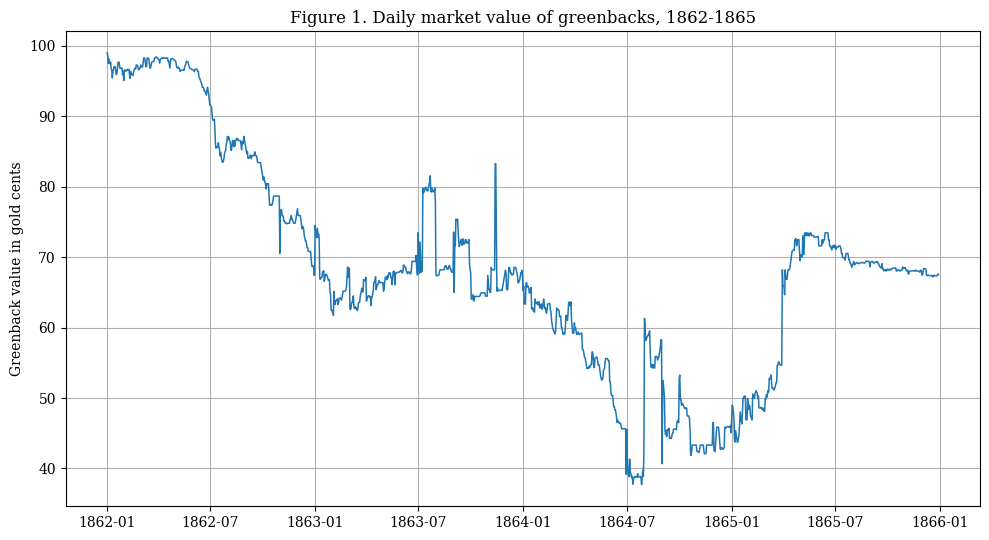

In [37]:
plt.figure(figsize=(10, 5.5))
plt.plot(greenback_daily["date"], greenback_daily["midpoint"], linewidth=1.1)
plt.title("Figure 1. Daily market value of greenbacks, 1862-1865")
plt.ylabel("Greenback value in gold cents")
plt.xlabel("")
plt.tight_layout()
plt.show()


## 4. Reproduce Figure 2: normalized monthly series


In [38]:
plot_df = pd.DataFrame(
    {
        "Gold price of greenbacks": normalize_to_base_100(monthly["gold_price_greenbacks"]),
        "General price index": normalize_to_base_100(monthly["general_price_index"]),
        "Wholesale price index": normalize_to_base_100(monthly["wholesale_price_index"]),
    },
    index=monthly.index,
)
plot_df.head()


,Gold price of greenbacks,General price index,Wholesale price index
1862-01-01,100.0000,100.0000,100.0000
1862-02-01,101.0352,101.3333,101.0204
1862-03-01,99.3890,100.0000,100.0000
1862-04-01,99.0863,100.0000,100.0000
1862-05-01,100.8264,98.6667,96.9388


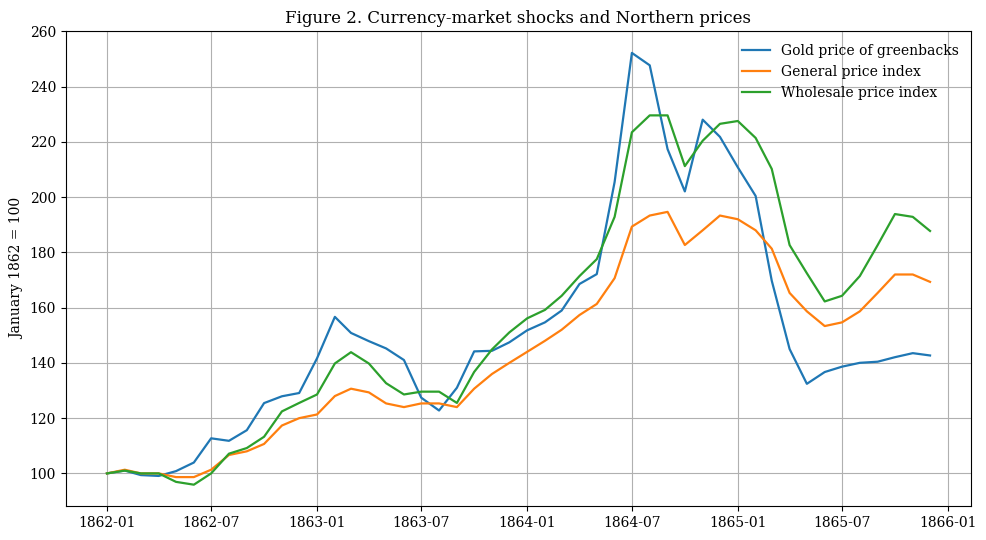

In [39]:
plt.figure(figsize=(10, 5.5))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], linewidth=1.6, label=col)
plt.title("Figure 2. Currency-market shocks and Northern prices")
plt.ylabel("January 1862 = 100")
plt.xlabel("")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 5. Appendix Figure A1: monthly log changes


In [40]:
fig_df = monthly[["dln_gold_price_greenbacks", "dln_wholesale_price_index"]].dropna()
fig_df.head()


,dln_gold_price_greenbacks,dln_wholesale_price_index
1862-02-01,0.0103,0.0102
1862-03-01,-0.0164,-0.0102
1862-04-01,-0.0031,0.0000
1862-05-01,0.0174,-0.0311
1862-06-01,0.0304,-0.0106


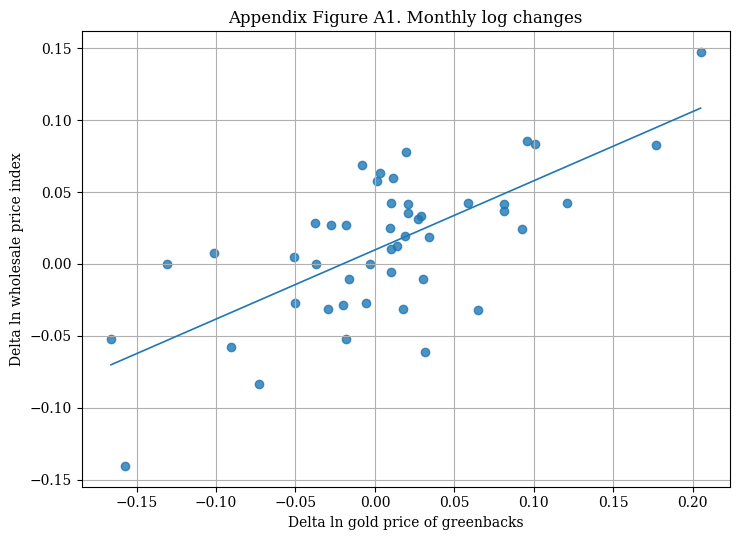

In [41]:
plt.figure(figsize=(7.5, 5.5))
plt.scatter(fig_df["dln_gold_price_greenbacks"], fig_df["dln_wholesale_price_index"], alpha=0.8)
m, b = np.polyfit(fig_df["dln_gold_price_greenbacks"], fig_df["dln_wholesale_price_index"], 1)
x = np.linspace(fig_df["dln_gold_price_greenbacks"].min(), fig_df["dln_gold_price_greenbacks"].max(), 100)
plt.plot(x, m * x + b, linewidth=1.2)
plt.title("Appendix Figure A1. Monthly log changes")
plt.xlabel("Delta ln gold price of greenbacks")
plt.ylabel("Delta ln wholesale price index")
plt.tight_layout()
plt.show()


## 6. Table 1: pass-through regressions

The paper reports contemporaneous regressions and distributed-lag specifications with HAC(1) standard errors.


In [42]:
# Run the regression models
results = []
results.extend(distributed_lag_result(monthly, "dln_general_price_index", "General price index"))
results.extend(distributed_lag_result(monthly, "dln_wholesale_price_index", "Wholesale price index"))

table1 = results_to_table(results)
table1


,Dependent variable,Model,Delta ln G_t,Lag 1,Lag 2,Cum. 0-2,N,R^2
0,General price index,Contemp.,0.325 (0.051),,,0.325 (0.051),47,0.4780
1,General price index,DL(0-2),0.214 (0.038),0.240 (0.052),0.051 (0.028),0.505 (0.043),45,0.7520
2,Wholesale price index,Contemp.,0.481 (0.072),,,0.481 (0.072),47,0.4770
3,Wholesale price index,DL(0-2),0.332 (0.056),0.325 (0.075),0.094 (0.043),0.751 (0.061),45,0.7270


In [43]:
# Optional: inspect one regression in full statsmodels form
X_example = pd.DataFrame({
    "dln_G_t": monthly["dln_gold_price_greenbacks"],
    "lag1": monthly["dln_gold_price_greenbacks"].shift(1),
    "lag2": monthly["dln_gold_price_greenbacks"].shift(2),
})
res_example, cov_example, aligned_example = fit_ols_hac(monthly["dln_wholesale_price_index"], X_example, nlags=1)
print(res_example.summary())


                                OLS Regression Results                               
Dep. Variable:     dln_wholesale_price_index   R-squared:                       0.727
Model:                                   OLS   Adj. R-squared:                  0.707
Method:                        Least Squares   F-statistic:                     36.43
Date:                       Sun, 05 Apr 2026   Prob (F-statistic):           1.22e-11
Time:                               16:14:03   Log-Likelihood:                 99.023
No. Observations:                         45   AIC:                            -190.0
Df Residuals:                             41   BIC:                            -182.8
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

## 7. Short textual results for presentation use


In [44]:
print(f"Greenback value starts at {monthly['greenback_value_cents'].iloc[0]:.1f} cents in January 1862.")
print(f"Greenback value trough: {monthly['greenback_value_cents'].min():.1f} cents in {monthly['greenback_value_cents'].idxmin():%B %Y}.")
print(f"Greenback value in December 1865: {monthly.loc[pd.Timestamp('1865-12-01'), 'greenback_value_cents']:.1f} cents.")
print(f"General price index peak: {monthly['general_price_index'].max():.0f} in {monthly['general_price_index'].idxmax():%B %Y}.")
print(f"Wholesale price index peak: {monthly['wholesale_price_index'].max():.0f} in {monthly['wholesale_price_index'].idxmax():%B %Y}.")
print(f"Gold price of greenbacks peak: {monthly['gold_price_greenbacks'].idxmax():%B %Y}.")


Greenback value starts at 97.6 cents in January 1862.
Greenback value trough: 38.7 cents in July 1864.
Greenback value in December 1865: 68.4 cents.
General price index peak: 146 in September 1864.
Wholesale price index peak: 225 in August 1864.
Gold price of greenbacks peak: July 1864.


## 8. Export cleaned data, figures, and tables


In [45]:
# Save cleaned datasets
greenback_daily.to_csv(OUTDIR / "clean_daily_greenback_data.csv", index=False)
monthly.to_csv(OUTDIR / "clean_monthly_data.csv", index=True, index_label="date")

# Save Table 1
table1.to_csv(OUTDIR / "table1_pass_through.csv", index=False)
(OUTDIR / "table1_pass_through.tex").write_text(table1.to_latex(index=False, escape=False), encoding="utf-8")

# Save figures individually
fig = plt.figure(figsize=(10, 5.5))
plt.plot(greenback_daily["date"], greenback_daily["midpoint"], linewidth=1.1)
plt.title("Figure 1. Daily market value of greenbacks, 1862-1865")
plt.ylabel("Greenback value in gold cents")
plt.xlabel("")
plt.tight_layout()
fig.savefig(OUTDIR / "figure1_daily_greenback_value.png", dpi=200)
plt.close(fig)

fig = plt.figure(figsize=(10, 5.5))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], linewidth=1.6, label=col)
plt.title("Figure 2. Currency-market shocks and Northern prices")
plt.ylabel("January 1862 = 100")
plt.xlabel("")
plt.legend(frameon=False)
plt.tight_layout()
fig.savefig(OUTDIR / "figure2_normalized_series.png", dpi=200)
plt.close(fig)

fig = plt.figure(figsize=(7.5, 5.5))
plt.scatter(fig_df["dln_gold_price_greenbacks"], fig_df["dln_wholesale_price_index"], alpha=0.8)
plt.plot(x, m * x + b, linewidth=1.2)
plt.title("Appendix Figure A1. Monthly log changes")
plt.xlabel("Delta ln gold price of greenbacks")
plt.ylabel("Delta ln wholesale price index")
plt.tight_layout()
fig.savefig(OUTDIR / "appendix_figure_a1_log_changes.png", dpi=200)
plt.close(fig)

summary_lines = [
    "Sample: January 1862 to December 1865",
    f"Monthly observations: {len(monthly)}",
    f"Greenback value starts at {monthly['greenback_value_cents'].iloc[0]:.1f} cents in January 1862.",
    f"Greenback value trough: {monthly['greenback_value_cents'].min():.1f} cents in {monthly['greenback_value_cents'].idxmin():%B %Y}.",
    f"Greenback value in December 1865: {monthly.loc[pd.Timestamp('1865-12-01'), 'greenback_value_cents']:.1f} cents.",
    f"General price index peak: {monthly['general_price_index'].max():.0f} in {monthly['general_price_index'].idxmax():%B %Y}.",
    f"Wholesale price index peak: {monthly['wholesale_price_index'].max():.0f} in {monthly['wholesale_price_index'].idxmax():%B %Y}.",
    f"Gold price of greenbacks peak: {monthly['gold_price_greenbacks'].idxmax():%B %Y}.",
]
(OUTDIR / "summary_stats.txt").write_text("".join(summary_lines), encoding="utf-8")

print("Saved outputs to:", OUTDIR.resolve())
print(sorted(p.name for p in OUTDIR.iterdir()))


Saved outputs to: /Users/miguel/workspace/american-civl-war/output
['appendix_figure_a1_log_changes.png', 'clean_daily_greenback_data.csv', 'clean_monthly_data.csv', 'figure1_daily_greenback_value.png', 'figure2_normalized_series.png', 'summary_stats.txt', 'table1_pass_through.csv', 'table1_pass_through.tex']


## 9. Notes for extending the notebook

Natural next steps:

- add alternative lag lengths
- add event-window overlays for key wartime dates
- add robustness checks using different monthly aggregations of the daily greenback series
- compare pass-through before and after the summer of 1864
